# MIL-Based Sensor Design Example

This notebook demonstrates the MILSensors library for optimal sensor placement using the Minimizing Information Loss (MIL) criterion. We'll work with a synthetic spatiotemporal temperature dataset that mimics real-world environmental monitoring scenarios.

## What we'll cover:
1. Generate a synthetic spatiotemporal temperature dataset
2. Train a spatiotemporal Gaussian Process model
3. Extract optimal sensor locations (inducing points)
4. Visualize results and uncertainty quantification


In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np

from milsensors.sensor_design import train_and_extract

## Step 1: Generate Synthetic Dataset

Our synthetic dataset models temperature over an irregular spatial domain with:
- Diurnal cycles with spatially-varying amplitude and phase
- Transient heatwave events
- Spatially-correlated noise following an AR(1) process


In [2]:
# Import the data generator
import sys

sys.path.append("../data")
from generate_synthetic_temperature import generate_dataset

# Generate dataset with 7 days of hourly data on an irregular domain
print("Generating synthetic dataset...")
air_temp_timeseries = generate_dataset(days=7, seed=42)
print(f"Dataset shape: {air_temp_timeseries.shape}")
print(
    f"Time range: {air_temp_timeseries[:, 0, 0].min():.0f} to {air_temp_timeseries[:, 0, 0].max():.0f} hours"
)
print(
    f"Temperature range: {air_temp_timeseries[:, :, 3].min():.1f} to {air_temp_timeseries[:, :, 3].max():.1f} °C"
)

# Save for use with sensor_design module
DATA_PATH = "synthetic_temp_demo.npz"
np.savez_compressed(DATA_PATH, air_temp_timeseries=air_temp_timeseries)

Generating synthetic dataset...
Dataset shape: (168, 278, 4)
Time range: 0 to 167 hours
Temperature range: 21.4 to 47.2 °C


## Step 2: Visualize the Domain

Let's examine the spatial domain and temperature patterns:


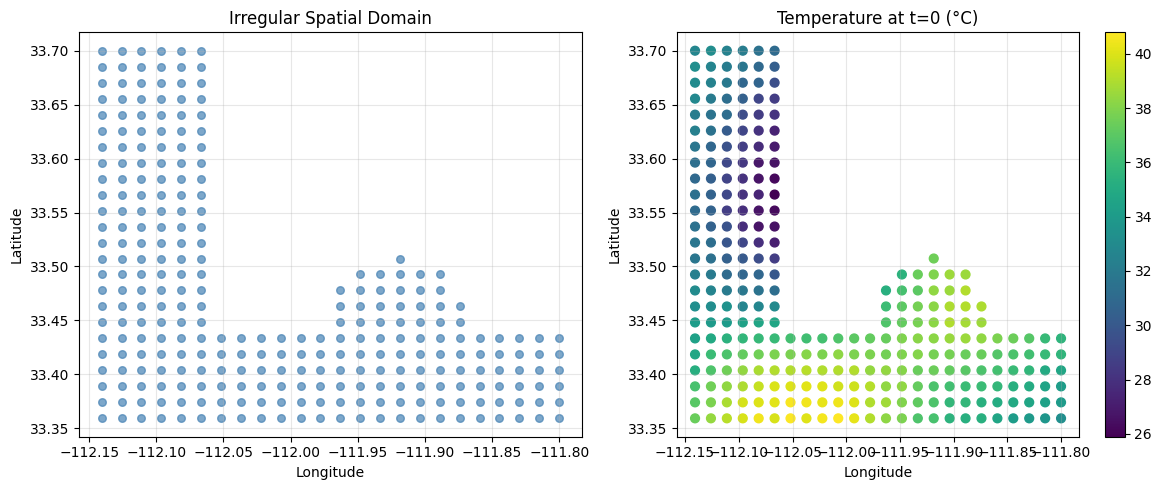

In [3]:
# Extract coordinates and initial temperature
lats = air_temp_timeseries[0, :, 1]
lons = air_temp_timeseries[0, :, 2]
temp_t0 = air_temp_timeseries[0, :, 3]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Domain shape
ax1.scatter(lons, lats, s=30, c="steelblue", alpha=0.7)
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
ax1.set_title("Irregular Spatial Domain")
ax1.grid(True, alpha=0.3)

# Temperature at t=0
sc = ax2.scatter(lons, lats, c=temp_t0, s=40, cmap="viridis")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
ax2.set_title("Temperature at t=0 (°C)")
plt.colorbar(sc, ax=ax2)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 3: Train Spatiotemporal GP and Extract Optimal Sensors

Now we use the MILSensors library to:
1. Train a spatiotemporal variational Gaussian Process
2. Extract optimal sensor locations (inducing points)
3. Obtain prediction uncertainties


In [4]:
print("Training spatiotemporal GP model...")
artifacts = train_and_extract(
    seed=42,
    num_inducing=5,  # Number of optimal sensor locations to find
    num_time_steps=24 * 7,  # 7 days hourly
    dataset="phoenix",  # Required but unused for npz data
    data_file=DATA_PATH,
    spatial_kern="matern32",
    temp_kern="subbandmix",  # Captures diurnal + long-term patterns
    noise_level=0.05,
    iters=50,  # Reduced for demo speed
    parallel=False,
)

print("Training complete!")
print(f"RMSE: {artifacts['rmse']:.3f} °C")
print(f"NLPD: {artifacts['nlpd']:.3f}")

Training spatiotemporal GP model...


/Users/dwaxman/Downloads/MILSensors/.venv/lib/python3.11/site-packages/jax/_src/numpy/lax_numpy.py:3527: UserWarning: 'kind' argument to argsort is ignored; only 'stable' sorts are supported.
  warnings.warn("'kind' argument to argsort is ignored; only 'stable' sorts "


############
Starting Training Loop
############
iter 50: energy: 337634.6577
optimisation time: 153.45 secs
average iter time: 3.07 secs


Training complete!
RMSE: 1.169 °C
NLPD: 4.710


## Step 4: Analyze Optimal Sensor Locations

The optimal sensor locations (inducing points) are learned during training. Let's visualize where the model thinks sensors should be placed:


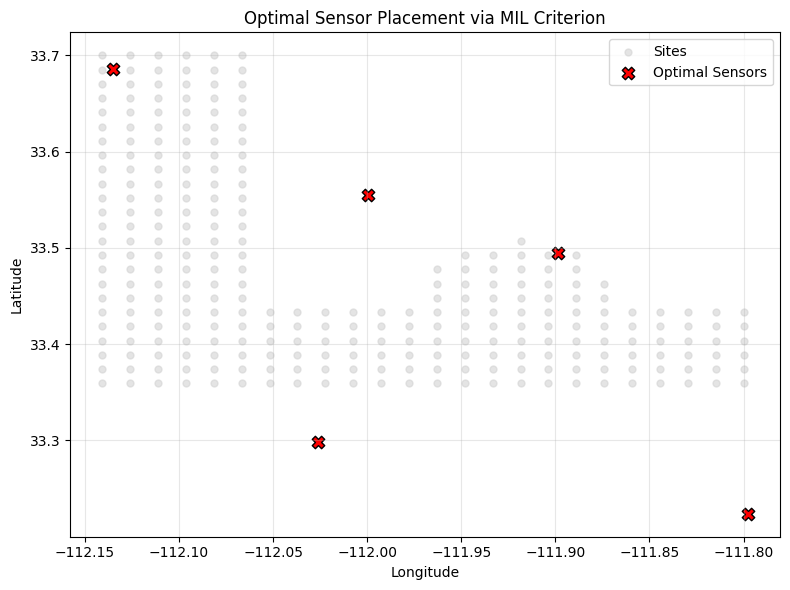

Placed 5 sensors optimally across the domain


In [5]:
# Extract learned inducing points and convert back to physical coordinates
Z_std = artifacts["z"]  # Standardized coordinates
mus, stds = artifacts["mus"], artifacts["stds"]
Z_lat = mus[1] + stds[1] * Z_std[:, 0]  # Convert back to lat/lon
Z_lon = mus[2] + stds[2] * Z_std[:, 1]

plt.figure(figsize=(8, 6))
plt.scatter(lons, lats, s=25, c="lightgray", alpha=0.6, label="Sites")
plt.scatter(
    Z_lon,
    Z_lat,
    s=80,
    c="red",
    marker="X",
    edgecolor="black",
    linewidth=1,
    label="Optimal Sensors",
)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Optimal Sensor Placement via MIL Criterion")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Placed {len(Z_lat)} sensors optimally across the domain")

## Summary

This example demonstrated the MILSensors workflow:

1. **Data Generation**: Created realistic synthetic spatiotemporal temperature data
2. **Model Training**: Used spatiotemporal variational GPs with MIL criterion
3. **Sensor Optimization**: Automatically found optimal sensor locations
4. **Evaluation**: Assessed prediction accuracy and uncertainty quantification

The MIL criterion naturally balances:
- **Spatial coverage**: Sensors spread across the domain
- **Information content**: Sensors placed where they reduce uncertainty most
- **Temporal dynamics**: Accounting for time-varying correlations

This approach is particularly valuable for environmental monitoring where sensor placement decisions have significant cost and logistical implications.


In [6]:
# Clean up temporary files
if os.path.exists(DATA_PATH):
    os.remove(DATA_PATH)
    print("Cleaned up temporary data file")

Cleaned up temporary data file
